In [1]:
#importing libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms , datasets
from torch.utils.data import DataLoader, random_split, Subset

train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )   
])

# loading dataset
full_train = datasets.ImageFolder(
    root="E:\\DeepLPytorch\Projects\\cat_dog_dataset\\PetImages",
    transform = train_transform
)

full_eval = datasets.ImageFolder(
    root="E:\\DeepLPytorch\Projects\\cat_dog_dataset\\PetImages",
    transform = eval_transform
)

<>:30: SyntaxWarning: invalid escape sequence '\P'
<>:35: SyntaxWarning: invalid escape sequence '\P'
<>:30: SyntaxWarning: invalid escape sequence '\P'
<>:35: SyntaxWarning: invalid escape sequence '\P'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19336\2196442857.py:30: SyntaxWarning: invalid escape sequence '\P'
  root="E:\\DeepLPytorch\Projects\\cat_dog_dataset\\PetImages",
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19336\2196442857.py:35: SyntaxWarning: invalid escape sequence '\P'
  root="E:\\DeepLPytorch\Projects\\cat_dog_dataset\\PetImages",


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

Using device:  cpu


In [3]:
# train-val-test split
num = len(full_train)
train_size = int(0.7*num)
val_size = int(0.15*num)
test_size = num - train_size - val_size

In [4]:
train_subset, val_subset, test_subset = random_split(
    range(num),
    [train_size, val_size, test_size],
    generator = torch.Generator().manual_seed(42)
)

train_data = Subset(full_train, train_subset.indices)
val_data = Subset(full_eval, val_subset.indices)
test_data = Subset(full_eval, test_subset.indices)

In [5]:
#creating data loaders
train_loader = DataLoader(
    train_data,
    batch_size=100,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=100,
    shuffle=False
)
test_loader = DataLoader(
    test_data,
    batch_size=100,
    shuffle=False
)

In [6]:
#checking data length
print(len(train_data))
print(len(val_data))
print(len(test_data))

15015
3217
3219


In [7]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            nn.Linear(64*16*16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 64),
            nn.ReLU(),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        x = self.classifier(x)

        return x
    
model = MyModel().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr=0.001)

epochs = 15

best_val = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for image, label in train_loader:
        image = image.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        output = model(image)
        loss = loss_fn(output, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        prediction = output.argmax(dim=1)
        correct += (prediction == label).sum().item()
        total += label.size(0)

    train_accuracy = (correct / total) * 100

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for image, label in val_loader:
           image = image.to(device)
           label = label.to(device)

           output = model(image)
           prediction = output.argmax(dim=1)

           correct += (prediction==label).sum().item()
           total += label.size(0)

    val_accuracy = (correct/total) * 100

    if best_val < val_accuracy:
        best_val = val_accuracy
        torch.save(model.state_dict(), "Cat_Dog.pth")
        print("Best Model saved!")
    print(f"Epoch: {epoch+1}/{epochs} | Loss: {(total_loss/len(train_loader)):.4f} | Train Accuracy: {train_accuracy:.4f} | Validation Accuracy: {val_accuracy:.4f}")    

Best Model saved!
Epoch: 1/15 | Loss: 0.6369 | Train Accuracy: 63.8295 | Validation Accuracy: 67.0500
Best Model saved!
Epoch: 2/15 | Loss: 0.5321 | Train Accuracy: 73.6730 | Validation Accuracy: 75.3808
Best Model saved!
Epoch: 3/15 | Loss: 0.4800 | Train Accuracy: 76.9630 | Validation Accuracy: 78.0541
Best Model saved!
Epoch: 4/15 | Loss: 0.4467 | Train Accuracy: 78.8944 | Validation Accuracy: 79.0799
Best Model saved!
Epoch: 5/15 | Loss: 0.4207 | Train Accuracy: 80.9590 | Validation Accuracy: 80.7274
Best Model saved!
Epoch: 6/15 | Loss: 0.3961 | Train Accuracy: 82.1379 | Validation Accuracy: 81.2869
Best Model saved!
Epoch: 7/15 | Loss: 0.3823 | Train Accuracy: 82.6707 | Validation Accuracy: 82.9655
Epoch: 8/15 | Loss: 0.3581 | Train Accuracy: 83.9494 | Validation Accuracy: 82.2505
Best Model saved!
Epoch: 9/15 | Loss: 0.3428 | Train Accuracy: 84.9950 | Validation Accuracy: 83.6494
Best Model saved!
Epoch: 10/15 | Loss: 0.3294 | Train Accuracy: 85.2814 | Validation Accuracy: 84.45

In [8]:
#testing
model.load_state_dict(torch.load("Cat_Dog.pth"))
model.eval()

correct = 0
total = 0
with torch.no_grad():
    for image, label in test_loader:
        image = image.to(device)
        label = label.to(device)

        output = model(image)
        prediction = output.argmax(dim=1)

        correct += (prediction==label).sum().item()
        total += label.size(0)

test_accuracy = (correct/total)*100
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 86.2690


# Inference

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


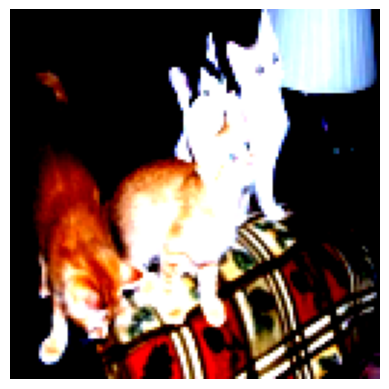

Actual Label: Cat
Predicted Label: Cat


In [9]:
import matplotlib.pyplot as plt

index = 50
image, true_label = test_data[index]

plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.show()

image = image.unsqueeze(0).to(device)
with torch.no_grad():
    output = model(image)
    prediction = output.argmax(dim=1).to(device)

    predicted_label = "Cat" if prediction.item() == 0 else "Dog"
    true_label = "Cat" if true_label == 0 else "Dog"

print(f"Actual Label: {true_label}")
print(f"Predicted Label: {predicted_label}")